<a href="https://colab.research.google.com/github/AhmadKhdair/BinX-AI-ML-Internship/blob/main/week-7/d3/03_RNN_LSTM_Sequential_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Day 3: RNNs and LSTMs for ECG Sequences

For Day 3 I am using the ECG heartbeat dataset provided for the session. I use the MIT-BIH files from the archive because they already give a train/test split and a five-class sequence-classification problem.

Each row is one heartbeat. The first 187 values are ordered ECG samples and the last value is the class label. The required comparison is `SimpleRNN` against `LSTM`. I also keep a dense baseline and a GRU run beside them so the result is not interpreted too narrowly. If the dense model is stronger, I say that clearly instead of forcing the recurrent model to look better than it is.


## 1. Day 3 Scope

The main points I want to show in this notebook are:

- why this ECG input should be treated as a sequence;
- how the input shape changes from `187` values to `187 x 1` timesteps/features;
- a plain RNN baseline with a recurrent hidden state;
- an LSTM on the same split and training setup;
- a validation-based comparison between the RNN and LSTM;
- a dense baseline check, because a fixed-length ECG row can also be learned as a feature vector;
- a final test evaluation for the selected recurrent model, with the dense baseline reported beside it;
- a short order-ablation check to see what happens when the ECG timestep order is destroyed.

A GRU is included as a small bonus because it is part of the Day 3 theory. It is not used as a replacement for the required LSTM experiment.


In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. The Sequence Idea I Am Using

A dense network sees the 187 values as one flat vector. A recurrent layer reads them in order. At timestep `t`, a plain RNN combines the current ECG value `x_t` with the previous hidden state `h_(t-1)` and produces a new hidden state.

`h_t = activation(x_t W_x + h_(t-1) W_h + b)`

The same recurrent weights are reused across all timesteps. During backpropagation, the gradient has to pass through many recurrent steps. Because the chain rule multiplies local effects across those steps, the gradient can become very small or very large. This is the vanishing/exploding-gradient issue behind the long-term-memory weakness of a plain RNN.

LSTM keeps the recurrent idea but adds a separate cell state and learned gates that control what is kept, added, and exposed. GRU uses a simpler gated design with fewer gates and no separate cell state.

I am not using an `Embedding` layer in this notebook. Embeddings are useful when the sequence starts as token IDs, such as text. Here every timestep is already a real ECG amplitude value, so an embedding would not match the input type.

## 3. Imports and Reproducibility

I keep one random seed across the split and model initialization so the comparison is easier to reproduce. The notebook is written for TensorFlow/Keras, which is the framework used in the Week 7 material.

In [2]:
from pathlib import Path
import os
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for this notebook. In a local environment run: pip install tensorflow"
    ) from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = False

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Load the Provided ECG Archive

The archive used for this day contains four files:

- `mitbih_train.csv`
- `mitbih_test.csv`
- `ptbdb_normal.csv`
- `ptbdb_abnormal.csv`

For the main Day 3 experiment I use the two MIT-BIH files. They already provide a train/test split, so I keep the original test file untouched and create validation data only from `mitbih_train.csv`.

The loader below works with either the original zip archive or directly with the two CSV files. In Colab it asks for the files only if they are not already available.

In [3]:
TRAIN_NAME = "mitbih_train.csv"
TEST_NAME = "mitbih_test.csv"

cwd = Path.cwd().resolve()
search_roots = [cwd, Path("/content"), Path("/mnt/data")]
search_roots = [p for p in search_roots if p.exists()]


def find_file(filename):
    for root in search_roots:
        matches = list(root.rglob(filename))
        if matches:
            return matches[0]
    return None


def find_archive():
    env_path = os.getenv("WEEK7_ECG_ARCHIVE")
    if env_path and Path(env_path).exists():
        return Path(env_path)

    preferred_names = [
        "archive (4).zip",
        "archive.zip",
        "heartbeat.zip",
        "dataset.zip",
    ]
    for name in preferred_names:
        path = find_file(name)
        if path is not None:
            return path

    for root in search_roots:
        for path in root.rglob("*.zip"):
            try:
                with zipfile.ZipFile(path) as zf:
                    basenames = {Path(name).name for name in zf.namelist()}
                if {TRAIN_NAME, TEST_NAME}.issubset(basenames):
                    return path
            except zipfile.BadZipFile:
                continue
    return None


def upload_if_colab():
    try:
        from google.colab import files
    except ImportError:
        return []

    print("Upload the ECG zip archive or the MIT-BIH CSV files.")
    uploaded = files.upload()
    return [Path(name) for name in uploaded]


train_path = find_file(TRAIN_NAME)
test_path = find_file(TEST_NAME)
archive_path = None

if train_path is None or test_path is None:
    archive_path = find_archive()

if train_path is None and test_path is None and archive_path is None:
    upload_if_colab()
    train_path = find_file(TRAIN_NAME)
    test_path = find_file(TEST_NAME)
    archive_path = find_archive()

if archive_path is None and (train_path is None or test_path is None):
    raise FileNotFoundError(
        "Could not find the provided ECG archive or both MIT-BIH CSV files. "
        "Place archive (4).zip, mitbih_train.csv, and/or mitbih_test.csv beside the notebook."
    )

print("Train CSV:", train_path)
print("Test CSV:", test_path)
print("Archive:", archive_path)

Upload the ECG zip archive or the MIT-BIH CSV files.


Saving archive (4).zip to archive (4).zip
Train CSV: None
Test CSV: None
Archive: /content/archive (4).zip


In [4]:
def read_csv_from_archive(archive, filename):
    with zipfile.ZipFile(archive) as zf:
        candidates = [name for name in zf.namelist() if Path(name).name == filename]
        if not candidates:
            raise FileNotFoundError(f"{filename} was not found inside {archive}.")
        with zf.open(candidates[0]) as file_obj:
            return pd.read_csv(file_obj, header=None, dtype=np.float32)


def load_mitbih():
    if train_path is not None and test_path is not None:
        train = pd.read_csv(train_path, header=None, dtype=np.float32)
        test = pd.read_csv(test_path, header=None, dtype=np.float32)
    else:
        train = read_csv_from_archive(archive_path, TRAIN_NAME)
        test = read_csv_from_archive(archive_path, TEST_NAME)
    return train, test


train_df, test_df = load_mitbih()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head(3))

Train shape: (87554, 188)
Test shape: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Dataset Audit

Before training, I check the shape, labels, missing values, and signal range. The expected structure is 188 columns: 187 ordered ECG samples plus one label.

The MIT-BIH class mapping used by this dataset is:

- `0`: Normal beat (N)
- `1`: Supraventricular ectopic beat (S)
- `2`: Ventricular ectopic beat (V)
- `3`: Fusion beat (F)
- `4`: Unknown / unclassifiable beat (Q)

In [5]:
CLASS_NAMES = {
    0: "Normal (N)",
    1: "Supraventricular (S)",
    2: "Ventricular (V)",
    3: "Fusion (F)",
    4: "Unknown (Q)",
}

EXPECTED_COLUMNS = 188
if train_df.shape[1] != EXPECTED_COLUMNS or test_df.shape[1] != EXPECTED_COLUMNS:
    raise ValueError(
        f"Expected {EXPECTED_COLUMNS} columns (187 signal + 1 label), "
        f"got train={train_df.shape[1]}, test={test_df.shape[1]}."
    )

missing_train = int(train_df.isna().sum().sum())
missing_test = int(test_df.isna().sum().sum())

train_labels = train_df.iloc[:, -1].astype(np.int32)
test_labels = test_df.iloc[:, -1].astype(np.int32)

summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "signal_columns": [187, 187],
        "missing_values": [missing_train, missing_test],
        "signal_min": [train_df.iloc[:, :-1].min().min(), test_df.iloc[:, :-1].min().min()],
        "signal_max": [train_df.iloc[:, :-1].max().max(), test_df.iloc[:, :-1].max().max()],
    }
)

display(summary.round(4))
print("Train labels:", sorted(train_labels.unique().tolist()))
print("Test labels:", sorted(test_labels.unique().tolist()))

,split,rows,signal_columns,missing_values,signal_min,signal_max
0,train,87554,187,0,0.0,1.0
1,test,21892,187,0,0.0,1.0


Train labels: [0, 1, 2, 3, 4]
Test labels: [0, 1, 2, 3, 4]


,class,name,train_count,test_count,train_percent
0,0,Normal (N),72471,18118,82.77
1,1,Supraventricular (S),2223,556,2.54
2,2,Ventricular (V),5788,1448,6.61
3,3,Fusion (F),641,162,0.73
4,4,Unknown (Q),6431,1608,7.35


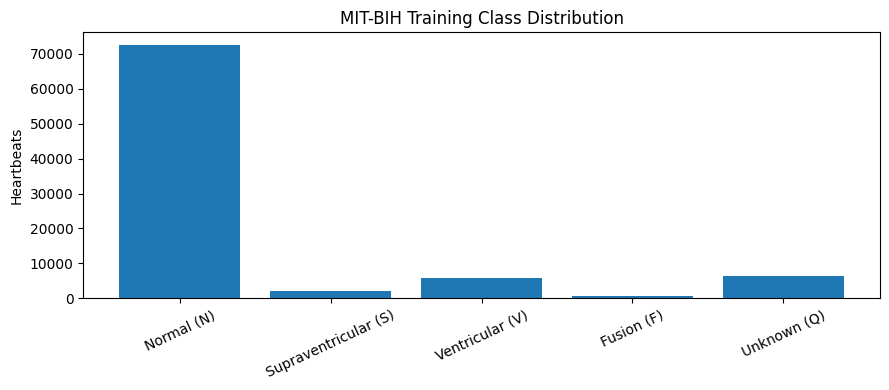

In [6]:
train_counts = train_labels.value_counts().sort_index()
test_counts = test_labels.value_counts().sort_index()

class_distribution = pd.DataFrame(
    {
        "class": range(5),
        "name": [CLASS_NAMES[i] for i in range(5)],
        "train_count": [int(train_counts.get(i, 0)) for i in range(5)],
        "test_count": [int(test_counts.get(i, 0)) for i in range(5)],
    }
)
class_distribution["train_percent"] = (
    class_distribution["train_count"] / class_distribution["train_count"].sum() * 100
)

display(class_distribution.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_distribution["name"], class_distribution["train_count"])
ax.set_title("MIT-BIH Training Class Distribution")
ax.set_ylabel("Heartbeats")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

The class distribution matters for evaluation. Normal beats are much more common than some arrhythmia classes, so accuracy by itself can hide weak minority-class performance. I will keep accuracy for readability, but I will use macro F1 as the main validation comparison because it gives each class equal weight.

## 6. Look at the ECG as a Sequence

I plot one heartbeat from each class before reshaping anything. This is the main reason I am treating the row as `187 timesteps x 1 feature` instead of just calling it 187 unrelated features.

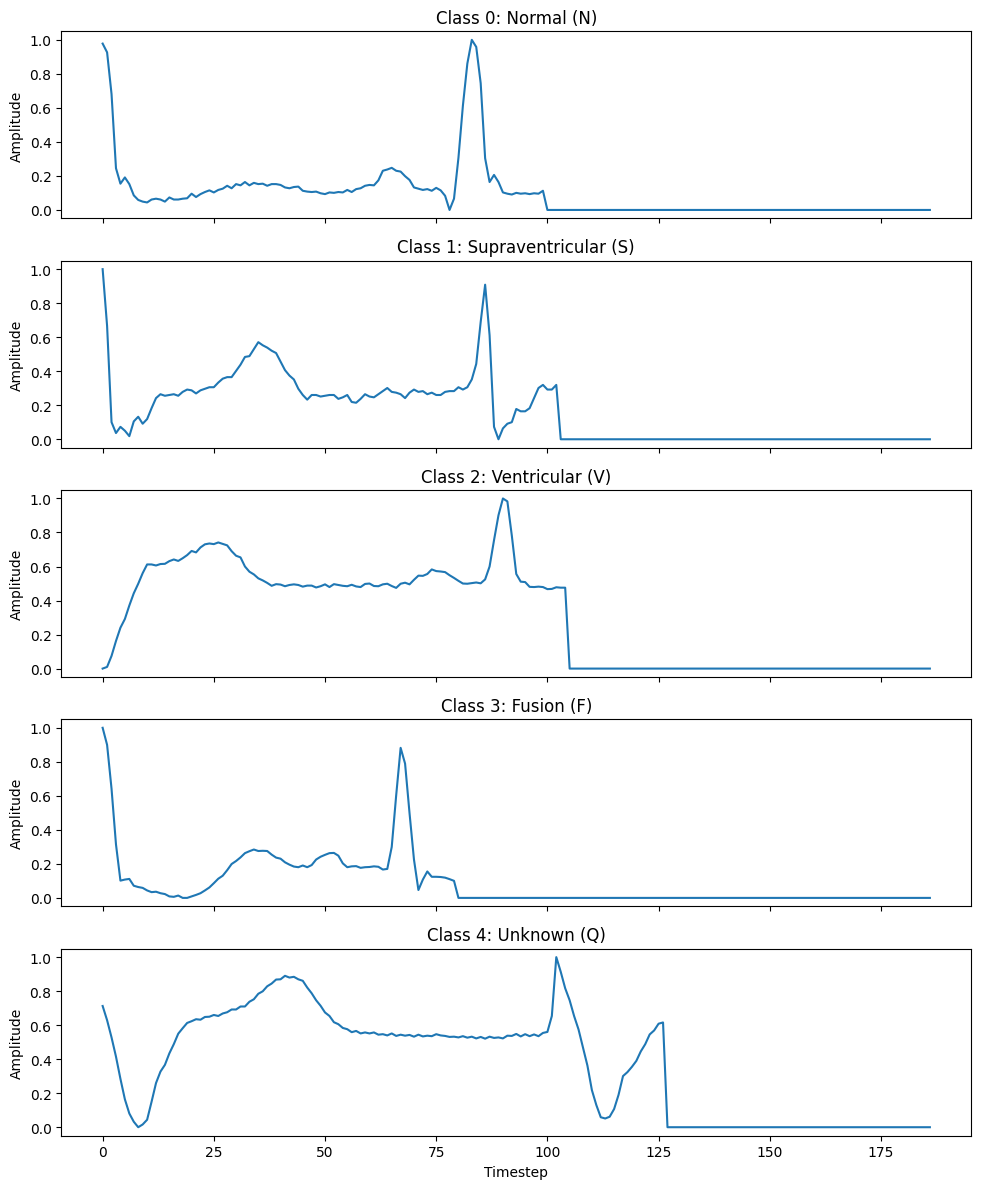

In [7]:
X_train_all = train_df.iloc[:, :-1].to_numpy(dtype=np.float32)
y_train_all = train_labels.to_numpy(dtype=np.int32)
X_test_flat = test_df.iloc[:, :-1].to_numpy(dtype=np.float32)
y_test = test_labels.to_numpy(dtype=np.int32)

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)
for class_id, ax in enumerate(axes):
    idx = np.flatnonzero(y_train_all == class_id)[0]
    ax.plot(X_train_all[idx])
    ax.set_title(f"Class {class_id}: {CLASS_NAMES[class_id]}")
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()

### Small extra check: average waveform by class

A single heartbeat can be noisy, so I also compare the average waveform of each class. This does not train a model; it only helps me see whether the classes have different temporal shapes before asking an RNN/LSTM to learn them.

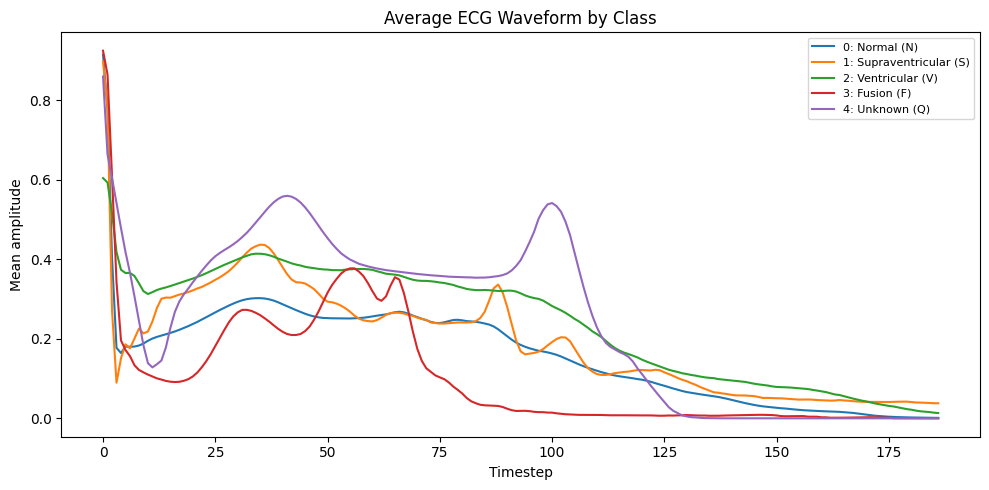

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for class_id in range(5):
    class_mean = X_train_all[y_train_all == class_id].mean(axis=0)
    ax.plot(class_mean, label=f"{class_id}: {CLASS_NAMES[class_id]}")
ax.set_title("Average ECG Waveform by Class")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean amplitude")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Train / Validation / Test Setup

The provided `mitbih_test.csv` stays untouched until the final evaluation. I split only the original training file into training and validation subsets, using stratification so the class proportions stay similar.

The signals are already normalized to roughly `[0, 1]` in the provided dataset, so I do not add another scaler. For the recurrent models I reshape each heartbeat from `(187,)` to `(187, 1)`:

`(samples, timesteps, features) = (samples, 187, 1)`

I also print the split counts after stratification. With this dataset, a high accuracy can be misleading because the normal class is much larger than the arrhythmia classes.


In [9]:
X_train_flat, X_val_flat, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_all,
)

X_train_seq = X_train_flat[..., np.newaxis]
X_val_seq = X_val_flat[..., np.newaxis]
X_test_seq = X_test_flat[..., np.newaxis]

print("Dense train shape:", X_train_flat.shape)
print("RNN/LSTM train shape:", X_train_seq.shape)
print("Validation shape:", X_val_seq.shape)
print("Test shape:", X_test_seq.shape)

split_balance = pd.DataFrame(
    {
        "class": range(5),
        "name": [CLASS_NAMES[i] for i in range(5)],
        "train": [int(np.sum(y_train == i)) for i in range(5)],
        "validation": [int(np.sum(y_val == i)) for i in range(5)],
        "test": [int(np.sum(y_test == i)) for i in range(5)],
    }
)
display(split_balance)


Dense train shape: (70043, 187)
RNN/LSTM train shape: (70043, 187, 1)
Validation shape: (17511, 187, 1)
Test shape: (21892, 187, 1)


,class,name,train,validation,test
0,0,Normal (N),57977,14494,18118
1,1,Supraventricular (S),1778,445,556
2,2,Ventricular (V),4630,1158,1448
3,3,Fusion (F),513,128,162
4,4,Unknown (Q),5145,1286,1608


In [10]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}

class_weight_df = pd.DataFrame(
    {
        "class": classes,
        "name": [CLASS_NAMES[int(c)] for c in classes],
        "weight": weights,
    }
)

display(class_weight_df.round(3))

,class,name,weight
0,0,Normal (N),0.242
1,1,Supraventricular (S),7.879
2,2,Ventricular (V),3.026
3,3,Fusion (F),27.307
4,4,Unknown (Q),2.723


I use the same class weights for all trainable models. The point is not to give one architecture an advantage; it is to stop the majority normal class from dominating the loss as strongly. The validation and test data are never resampled.

## 8. Model Definitions

I keep the training setup as similar as possible across models so the architecture is the main change.

- **Dense baseline:** non-recurrent reference using the flat 187-value vector.
- **SimpleRNN:** the required plain recurrent comparison.
- **LSTM:** the required gated recurrent model.
- **GRU:** small optional experiment from the Day 3 theory.

All models use the same output layer, optimizer, loss, batch size, class weights, and early-stopping rule.

In [11]:
NUM_CLASSES = 5
SEQUENCE_LENGTH = 187
BATCH_SIZE = 256
MAX_EPOCHS = 25
LEARNING_RATE = 1e-3
RUN_GRU_BONUS = True


def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_dense_baseline():
    model = keras.Sequential(
        [
            layers.Input(shape=(SEQUENCE_LENGTH,)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.20),
            layers.Dense(32, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="DenseBaseline",
    )
    return compile_model(model)


def build_simple_rnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(SEQUENCE_LENGTH, 1)),
            layers.SimpleRNN(64),
            layers.Dropout(0.20),
            layers.Dense(32, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="SimpleRNN",
    )
    return compile_model(model)


def build_lstm():
    model = keras.Sequential(
        [
            layers.Input(shape=(SEQUENCE_LENGTH, 1)),
            layers.LSTM(64),
            layers.Dropout(0.20),
            layers.Dense(32, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="LSTM",
    )
    return compile_model(model)


def build_gru():
    model = keras.Sequential(
        [
            layers.Input(shape=(SEQUENCE_LENGTH, 1)),
            layers.GRU(64),
            layers.Dropout(0.20),
            layers.Dense(32, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="GRU",
    )
    return compile_model(model)


for builder in [build_dense_baseline, build_simple_rnn, build_lstm, build_gru]:
    model = builder()
    print(f"{model.name}: {model.count_params():,} parameters")

DenseBaseline: 14,277 parameters
SimpleRNN: 6,469 parameters
LSTM: 19,141 parameters
GRU: 15,109 parameters


## 9. Training Helper

I select models from validation results, not from the test file. `EarlyStopping` monitors validation loss and restores the best weights from each run.

In [12]:
def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        )
    ]


def validation_metrics(model, X_val, y_val):
    probabilities = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
    predictions = probabilities.argmax(axis=1)
    return {
        "val_accuracy": accuracy_score(y_val, predictions),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, predictions),
        "val_macro_f1": f1_score(y_val, predictions, average="macro"),
        "val_weighted_f1": f1_score(y_val, predictions, average="weighted"),
        "val_macro_recall": recall_score(y_val, predictions, average="macro"),
    }


def train_experiment(name, model, X_train, X_val):
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=make_callbacks(),
        verbose=1,
    )
    elapsed = time.perf_counter() - start

    metrics = validation_metrics(model, X_val, y_val)
    metrics.update(
        {
            "model": name,
            "parameters": model.count_params(),
            "epochs_run": len(history.history["loss"]),
            "best_val_loss": float(min(history.history["val_loss"])),
            "training_seconds": elapsed,
        }
    )
    return history, metrics

## 10. Dense Baseline

This model is intentionally non-recurrent. It gives me a reference for whether the recurrent architectures add value on this fixed-length heartbeat representation.

I do not use the dense model to replace the required RNN/LSTM comparison. I keep it because it is an honest baseline: if a simpler model is stronger, the final notes should show that.


In [13]:
dense_model = build_dense_baseline()
dense_history, dense_metrics = train_experiment(
    "Dense baseline", dense_model, X_train_flat, X_val_flat
)
display(pd.DataFrame([dense_metrics]).round(4))

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5486 - loss: 0.9384 - val_accuracy: 0.6590 - val_loss: 0.8682
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6865 - loss: 0.6400 - val_accuracy: 0.7600 - val_loss: 0.6889
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7300 - loss: 0.5555 - val_accuracy: 0.7578 - val_loss: 0.6731
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7514 - loss: 0.5043 - val_accuracy: 0.7758 - val_loss: 0.6305
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7718 - loss: 0.4669 - val_accuracy: 0.7952 - val_loss: 0.5656
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7791 - loss: 0.4419 - val_accuracy: 0.7924 - val_loss: 0.5614
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7894 - loss: 0.4287 - val_accuracy: 0.8059 - val_loss: 0.5355
Epoch 8/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8027 - loss: 0.4049 - val_accuracy: 0.

,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall,model,parameters,epochs_run,best_val_loss,training_seconds
0,0.8826,0.8853,0.6779,0.9062,0.8853,Dense baseline,14277,25,0.3264,56.4776


## 11. Plain RNN

The `SimpleRNN` reads one ECG value at a time and carries a hidden state through the 187 timesteps. This is the direct recurrent baseline required for the Day 3 comparison.

In [14]:
rnn_model = build_simple_rnn()
rnn_history, rnn_metrics = train_experiment(
    "SimpleRNN", rnn_model, X_train_seq, X_val_seq
)
display(pd.DataFrame([rnn_metrics]).round(4))

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 54s 192ms/step - accuracy: 0.1348 - loss: 1.6109 - val_accuracy: 0.0294 - val_loss: 1.5698
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 52s 190ms/step - accuracy: 0.2323 - loss: 1.5881 - val_accuracy: 0.2733 - val_loss: 1.5008
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 52s 189ms/step - accuracy: 0.2684 - loss: 1.5184 - val_accuracy: 0.0344 - val_loss: 1.5444
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 81s 186ms/step - accuracy: 0.2814 - loss: 1.4753 - val_accuracy: 0.0236 - val_loss: 1.5612
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 51s 185ms/step - accuracy: 0.1522 - loss: 1.6249 - val_accuracy: 0.0855 - val_loss: 1.6084
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 52s 189ms/step - accuracy: 0.1501 - loss: 1.5782 - val_accuracy: 0.0598 - val_loss: 1.6804
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.


,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall,model,parameters,epochs_run,best_val_loss,training_seconds
0,0.2733,0.4257,0.2616,0.374,0.4257,SimpleRNN,6469,6,1.5008,341.7737


## 12. LSTM

The LSTM receives the same sequence and uses the same training setup. The main architecture change is its gated memory and cell state, which are designed to preserve useful information across longer recurrent paths more effectively than a plain RNN.

In [15]:
lstm_model = build_lstm()
lstm_history, lstm_metrics = train_experiment(
    "LSTM", lstm_model, X_train_seq, X_val_seq
)
display(pd.DataFrame([lstm_metrics]).round(4))

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2017 - loss: 1.5725 - val_accuracy: 0.0699 - val_loss: 1.5253
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1339 - loss: 1.4137 - val_accuracy: 0.2316 - val_loss: 1.4941
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3008 - loss: 1.2288 - val_accuracy: 0.3165 - val_loss: 1.3482
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3075 - loss: 1.1830 - val_accuracy: 0.3057 - val_loss: 1.3540
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3304 - loss: 1.1170 - val_accuracy: 0.2931 - val_loss: 1.3276
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3380 - loss: 1.0927 - val_accuracy: 0.2894 - val_loss: 1.3974
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3730 - loss: 1.0541 - val_accuracy: 0.3992 - val_loss: 1.2620
Epoch 8/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.2724 - loss: 1.4080 - val_accu

,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall,model,parameters,epochs_run,best_val_loss,training_seconds
0,0.3992,0.6416,0.2945,0.4784,0.6416,LSTM,19141,11,1.262,45.5002


## 13. GRU Bonus

This is a small extension, not a replacement for the required work. GRU keeps the gated-memory idea but uses a simpler recurrent cell than LSTM. I include it to see whether the lighter gated architecture is competitive on this relatively short ECG sequence.

In [16]:
gru_history = None
gru_metrics = None
gru_model = None

if RUN_GRU_BONUS:
    gru_model = build_gru()
    gru_history, gru_metrics = train_experiment(
        "GRU (bonus)", gru_model, X_train_seq, X_val_seq
    )
    display(pd.DataFrame([gru_metrics]).round(4))
else:
    print("GRU bonus skipped. Set RUN_GRU_BONUS = True to run it.")

Epoch 1/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2245 - loss: 1.5713 - val_accuracy: 0.0526 - val_loss: 1.5380
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1101 - loss: 1.4034 - val_accuracy: 0.2313 - val_loss: 1.4879
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2286 - loss: 1.2797 - val_accuracy: 0.2680 - val_loss: 1.4989
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2833 - loss: 1.2549 - val_accuracy: 0.3439 - val_loss: 1.3958
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3185 - loss: 1.1893 - val_accuracy: 0.3201 - val_loss: 1.3685
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3052 - loss: 1.1658 - val_accuracy: 0.2958 - val_loss: 1.3740
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2936 - loss: 1.1395 - val_accuracy: 0.2841 - val_loss: 1.3599
Epoch 8/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.2959 - loss: 1.0922 - val_accu

,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall,model,parameters,epochs_run,best_val_loss,training_seconds
0,0.301,0.6323,0.2532,0.3435,0.6323,GRU (bonus),15109,14,1.3416,55.7384


## 14. Training Curves

I look at training and validation loss together instead of trusting the final accuracy number alone. A widening train/validation gap would suggest overfitting, while both curves staying weak would suggest underfitting or an optimization problem.

The recurrent curves are the main Day 3 evidence. I also plot the dense and GRU runs because they are included in the comparison table.


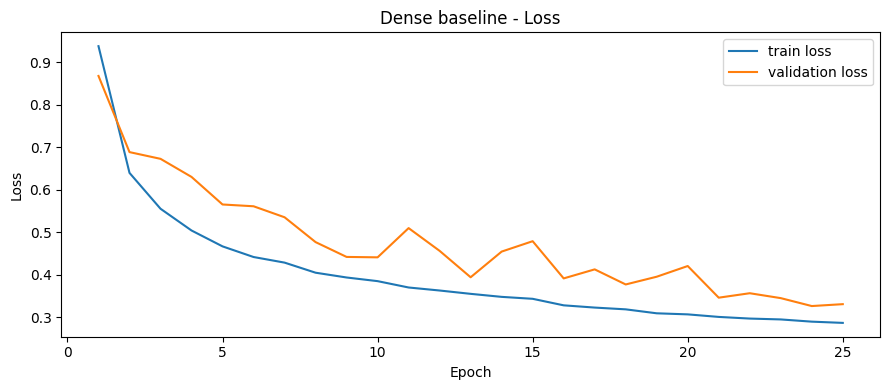

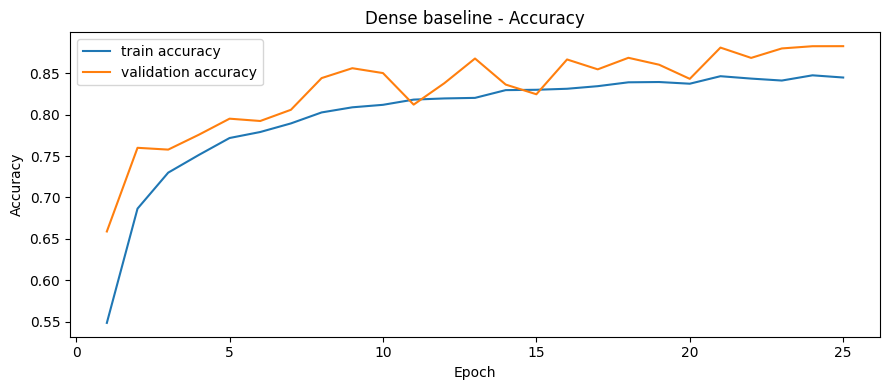

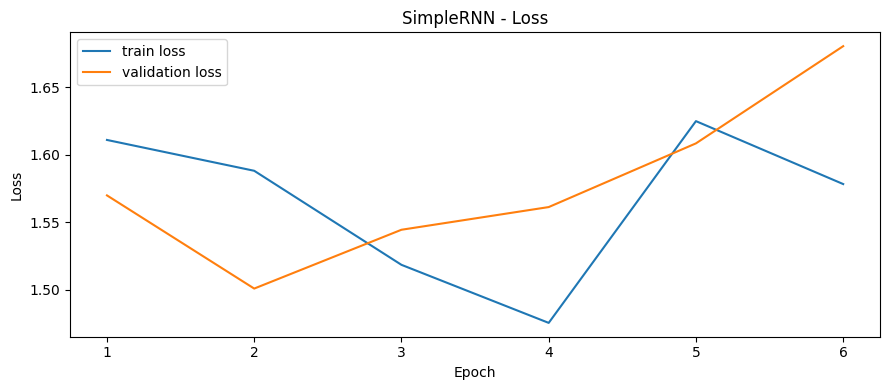

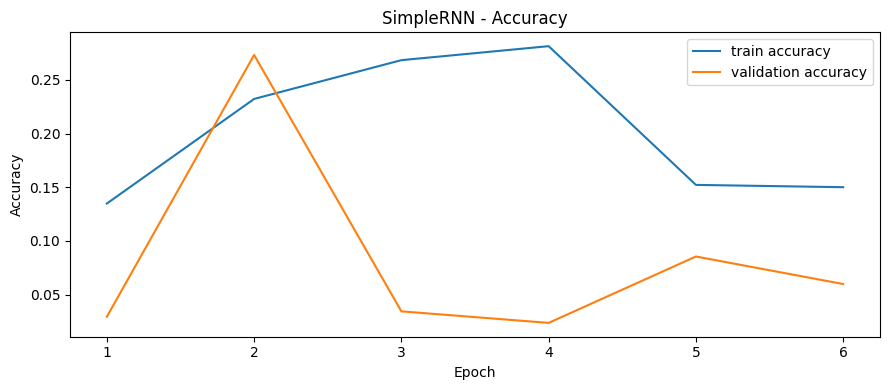

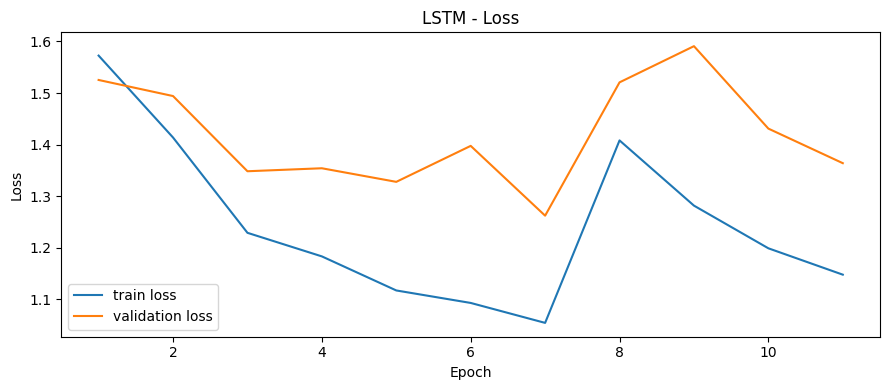

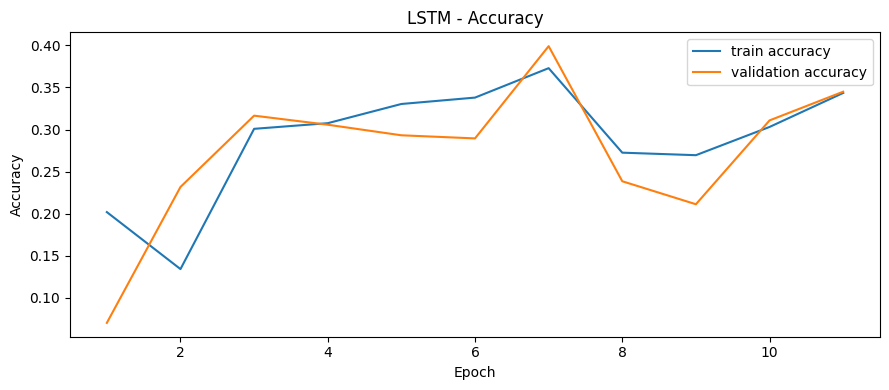

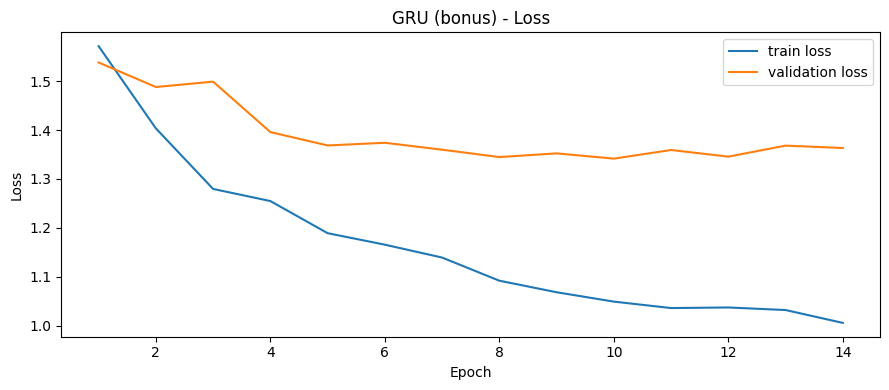

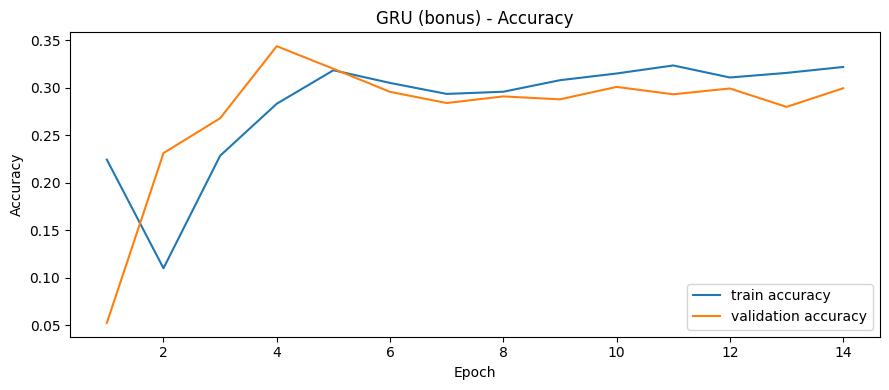

In [17]:
def plot_history(history, title):
    epochs = np.arange(1, len(history.history["loss"]) + 1)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, history.history["loss"], label="train loss")
    ax.plot(epochs, history.history["val_loss"], label="validation loss")
    ax.set_title(f"{title} - Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(epochs, history.history["accuracy"], label="train accuracy")
    ax.plot(epochs, history.history["val_accuracy"], label="validation accuracy")
    ax.set_title(f"{title} - Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_history(dense_history, "Dense baseline")
plot_history(rnn_history, "SimpleRNN")
plot_history(lstm_history, "LSTM")

if gru_history is not None:
    plot_history(gru_history, "GRU (bonus)")


## 15. Validation Comparison

For the required Day 3 decision, I compare `SimpleRNN` and `LSTM` first. The dense and GRU runs are supporting experiments, but the dense baseline is still important because it tells me whether sequence modeling actually helped this specific representation.

Because the dataset is imbalanced, I use validation macro F1 as the main ranking metric and keep accuracy/balanced accuracy beside it for context.


In [18]:
rows = [dense_metrics, rnn_metrics, lstm_metrics]
if gru_metrics is not None:
    rows.append(gru_metrics)

comparison = pd.DataFrame(rows).set_index("model")
comparison = comparison[
    [
        "parameters",
        "epochs_run",
        "best_val_loss",
        "val_accuracy",
        "val_balanced_accuracy",
        "val_macro_f1",
        "val_weighted_f1",
        "val_macro_recall",
        "training_seconds",
    ]
].sort_values("val_macro_f1", ascending=False)

display(comparison.round(4))

required_comparison = comparison.loc[["SimpleRNN", "LSTM"]].sort_values(
    "val_macro_f1", ascending=False
)
best_required_name = required_comparison.index[0]

print("Best required recurrent model by validation macro F1:", best_required_name)

,parameters,epochs_run,best_val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall,training_seconds
model,,,,,,,,,
Dense baseline,14277,25,0.3264,0.8826,0.8853,0.6779,0.9062,0.8853,56.4776
LSTM,19141,11,1.2620,0.3992,0.6416,0.2945,0.4784,0.6416,45.5002
SimpleRNN,6469,6,1.5008,0.2733,0.4257,0.2616,0.3740,0.4257,341.7737
GRU (bonus),15109,14,1.3416,0.3010,0.6323,0.2532,0.3435,0.6323,55.7384


Best required recurrent model by validation macro F1: LSTM


In [19]:
rnn_f1 = float(comparison.loc["SimpleRNN", "val_macro_f1"])
lstm_f1 = float(comparison.loc["LSTM", "val_macro_f1"])
dense_f1 = float(comparison.loc["Dense baseline", "val_macro_f1"])

rnn_acc = float(comparison.loc["SimpleRNN", "val_accuracy"])
lstm_acc = float(comparison.loc["LSTM", "val_accuracy"])
dense_acc = float(comparison.loc["Dense baseline", "val_accuracy"])

if lstm_f1 > rnn_f1:
    recurrent_direction = (
        f"The LSTM was stronger than SimpleRNN on validation macro F1 ({lstm_f1:.4f} vs {rnn_f1:.4f}). "
        "For the required recurrent comparison, the gated cell was the better choice in this run."
    )
elif rnn_f1 > lstm_f1:
    recurrent_direction = (
        f"The SimpleRNN was stronger than LSTM on validation macro F1 ({rnn_f1:.4f} vs {lstm_f1:.4f}). "
        "That would mean the extra LSTM complexity did not help on this run."
    )
else:
    recurrent_direction = (
        f"The RNN and LSTM produced the same validation macro F1 ({rnn_f1:.4f}). "
        "In this run, the extra LSTM complexity did not create a measurable advantage."
    )

if dense_f1 > max(rnn_f1, lstm_f1):
    baseline_note = (
        f"The dense baseline was stronger overall on validation macro F1 ({dense_f1:.4f}) "
        f"and validation accuracy ({dense_acc:.4f}). This matters: the LSTM satisfies the sequence-modeling task, "
        "but it is not the best model in this notebook."
    )
else:
    baseline_note = (
        f"The best recurrent model also beat the dense baseline on validation macro F1 "
        f"({max(rnn_f1, lstm_f1):.4f} vs {dense_f1:.4f})."
    )

display(Markdown(
    "### Required RNN vs LSTM result\n\n"
    + recurrent_direction
    + f"\n\nValidation accuracy was `{rnn_acc:.4f}` for SimpleRNN, `{lstm_acc:.4f}` for LSTM, "
    + f"and `{dense_acc:.4f}` for the dense baseline. "
    + "I keep macro F1 as the main comparison because of the class imbalance."
    + "\n\n"
    + baseline_note
))


### Required RNN vs LSTM result

The LSTM was stronger than SimpleRNN on validation macro F1 (0.2945 vs 0.2616). For the required recurrent comparison, the gated cell was the better choice in this run.

Validation accuracy was `0.2733` for SimpleRNN, `0.3992` for LSTM, and `0.8826` for the dense baseline. I keep macro F1 as the main comparison because of the class imbalance.

The dense baseline was stronger overall on validation macro F1 (0.6779) and validation accuracy (0.8826). This matters: the LSTM satisfies the sequence-modeling task, but it is not the best model in this notebook.

## 16. Does Order Matter? A Small Ablation

The Day 3 theory says the order of a sequence carries information. I check that directly on the selected recurrent model: I take the validation ECGs and randomly shuffle the timesteps inside each heartbeat, then evaluate the model again.

This is not a new training set and it is not a clinical robustness test. It only answers one narrow question: did the selected recurrent model depend on the original ECG order and waveform shape?


In [20]:
selected_required_model = lstm_model if best_required_name == "LSTM" else rnn_model

rng = np.random.default_rng(RANDOM_STATE)
X_val_shuffled = X_val_seq.copy()
for i in range(len(X_val_shuffled)):
    permutation = rng.permutation(SEQUENCE_LENGTH)
    X_val_shuffled[i, :, 0] = X_val_shuffled[i, permutation, 0]

ordered_metrics = validation_metrics(selected_required_model, X_val_seq, y_val)
shuffled_metrics = validation_metrics(selected_required_model, X_val_shuffled, y_val)

order_check = pd.DataFrame(
    [
        {"input": "Original order", **ordered_metrics},
        {"input": "Shuffled timesteps", **shuffled_metrics},
    ]
).set_index("input")

display(order_check.round(4))

,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_macro_recall
input,,,,,
Original order,0.3992,0.6416,0.2945,0.4784,0.6416
Shuffled timesteps,0.0348,0.1914,0.0266,0.0121,0.1914


In [21]:
ordered_f1 = float(order_check.loc["Original order", "val_macro_f1"])
shuffled_f1 = float(order_check.loc["Shuffled timesteps", "val_macro_f1"])
drop = ordered_f1 - shuffled_f1

if drop > 0.05:
    message = (
        f"Macro F1 dropped by {drop:.4f} after shuffling the timesteps. "
        "That is strong evidence that this recurrent model used the ECG order and waveform shape. "
        "It does not prove that the recurrent model is the best architecture overall."
    )
elif drop > 0:
    message = (
        f"Macro F1 dropped by {drop:.4f} after shuffling. "
        "Order is helping, although the drop is modest in this run."
    )
else:
    message = (
        f"Macro F1 did not drop after shuffling (change: {drop:.4f}). "
        "I would not claim from this run that the model learned useful order dependence; I would inspect the model and experiment setup before making that conclusion."
    )

display(Markdown("### Order-awareness check\n\n" + message))


### Order-awareness check

Macro F1 dropped by 0.2679 after shuffling the timesteps. That is strong evidence that this recurrent model used the ECG order and waveform shape. It does not prove that the recurrent model is the best architecture overall.

## 17. Final Test Evaluation

I select the better **required recurrent model** from validation macro F1, then use `mitbih_test.csv` once for the recurrent final report. I also report the dense baseline on the same test file because it had its own validation result and is part of the notebook comparison.

The test result is not used to choose between `SimpleRNN` and `LSTM`.


In [22]:
if best_required_name == "LSTM":
    final_recurrent_model = lstm_model
else:
    final_recurrent_model = rnn_model


def evaluate_test_model(name, model, X_test):
    start = time.perf_counter()
    probabilities = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    inference_seconds = time.perf_counter() - start
    predictions = probabilities.argmax(axis=1)

    metrics = {
        "model": name,
        "test_accuracy": accuracy_score(y_test, predictions),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "test_macro_f1": f1_score(y_test, predictions, average="macro"),
        "test_weighted_f1": f1_score(y_test, predictions, average="weighted"),
        "test_macro_recall": recall_score(y_test, predictions, average="macro"),
        "test_inference_seconds": inference_seconds,
    }
    return metrics, predictions


test_metrics, test_predictions = evaluate_test_model(
    best_required_name, final_recurrent_model, X_test_seq
)
dense_test_metrics, dense_test_predictions = evaluate_test_model(
    "Dense baseline", dense_model, X_test_flat
)

test_results = pd.DataFrame([test_metrics, dense_test_metrics]).set_index("model")
display(test_results.sort_values("test_macro_f1", ascending=False).round(4))


,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_macro_recall,test_inference_seconds
model,,,,,,
Dense baseline,0.8815,0.8813,0.6754,0.9051,0.8813,0.2484
LSTM,0.4022,0.6305,0.2955,0.4831,0.6305,0.4865


In [23]:
report = classification_report(
    y_test,
    test_predictions,
    labels=list(range(5)),
    target_names=[CLASS_NAMES[i] for i in range(5)],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).T

display(report_df.round(4))

class_rows = report_df.loc[[CLASS_NAMES[i] for i in range(5)]]
lowest_precision_class = class_rows["precision"].idxmin()
lowest_precision = float(class_rows.loc[lowest_precision_class, "precision"])
macro_recall = float(report_df.loc["macro avg", "recall"])
macro_f1 = float(report_df.loc["macro avg", "f1-score"])

display(Markdown(
    "### Test report interpretation\n\n"
    f"The selected recurrent model has macro recall `{macro_recall:.4f}` and macro F1 `{macro_f1:.4f}`. "
    "The class weights helped the model pay attention to rare classes, but the trade-off is visible in precision. "
    f"The weakest precision is for **{lowest_precision_class}** at `{lowest_precision:.4f}`, "
    "so I would not describe this as a production-ready ECG classifier. It is a Day 3 sequence-modeling experiment with clear class-imbalance behavior."
))


,precision,recall,f1-score,support
Normal (N),0.9567,0.3532,0.5160,18118.0000
Supraventricular (S),0.0620,0.7014,0.1139,556.0000
Ventricular (V),0.1569,0.2845,0.2023,1448.0000
Fusion (F),0.0613,0.9074,0.1148,162.0000
Unknown (Q),0.3750,0.9061,0.5305,1608.0000
accuracy,0.4022,0.4022,0.4022,0.4022
macro avg,0.3224,0.6305,0.2955,21892.0000
weighted avg,0.8317,0.4022,0.4831,21892.0000


### Test report interpretation

The selected recurrent model has macro recall `0.6305` and macro F1 `0.2955`. The class weights helped the model pay attention to rare classes, but the trade-off is visible in precision. The weakest precision is for **Fusion (F)** at `0.0613`, so I would not describe this as a production-ready ECG classifier. It is a Day 3 sequence-modeling experiment with clear class-imbalance behavior.

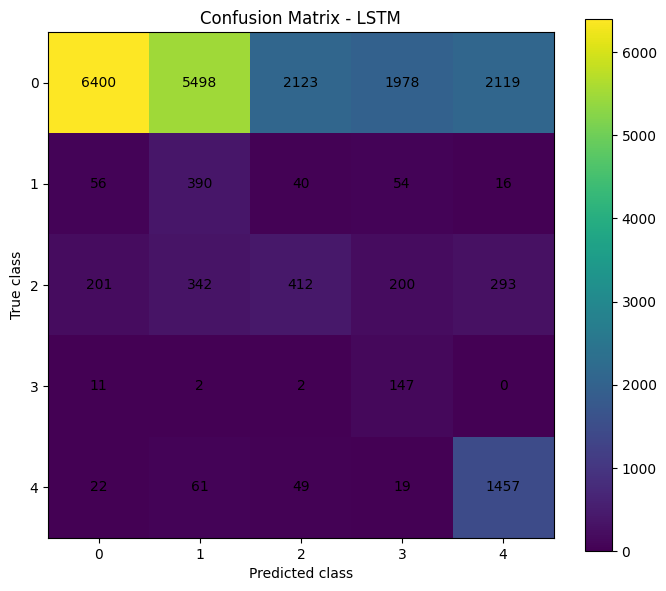

In [24]:
cm = confusion_matrix(y_test, test_predictions, labels=list(range(5)))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
fig.colorbar(im, ax=ax)
ax.set_title(f"Confusion Matrix - {best_required_name}")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks(range(5), labels=range(5))
ax.set_yticks(range(5), labels=range(5))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

In [25]:
selected_val_f1 = float(comparison.loc[best_required_name, "val_macro_f1"])
selected_val_acc = float(comparison.loc[best_required_name, "val_accuracy"])

recurrent_test_f1 = float(test_results.loc[best_required_name, "test_macro_f1"])
recurrent_test_acc = float(test_results.loc[best_required_name, "test_accuracy"])
dense_test_f1 = float(test_results.loc["Dense baseline", "test_macro_f1"])
dense_test_acc = float(test_results.loc["Dense baseline", "test_accuracy"])

if dense_test_f1 > recurrent_test_f1:
    overall_note = (
        f"The dense baseline was stronger on test macro F1 (`{dense_test_f1:.4f}`) "
        f"and test accuracy (`{dense_test_acc:.4f}`). So my final interpretation is not that LSTM is the best model; "
        "it is that LSTM was the better required recurrent model, while the simpler dense baseline was stronger overall for this fixed-length CSV representation."
    )
else:
    overall_note = (
        f"The selected recurrent model was also stronger than the dense baseline on test macro F1 "
        f"(`{recurrent_test_f1:.4f}` vs `{dense_test_f1:.4f}`)."
    )

final_text = (
    f"The selected recurrent model was **{best_required_name}** based on validation macro F1. "
    f"Its validation macro F1 was `{selected_val_f1:.4f}` with validation accuracy `{selected_val_acc:.4f}`. "
    f"On the held-out MIT-BIH test file it reached accuracy `{recurrent_test_acc:.4f}` "
    f"and macro F1 `{recurrent_test_f1:.4f}`. "
    "Because the dataset is imbalanced, I do not judge the model from accuracy alone; the per-class report and confusion matrix are part of the result. "
    + overall_note
)

display(Markdown("### Final result\n\n" + final_text))


### Final result

The selected recurrent model was **LSTM** based on validation macro F1. Its validation macro F1 was `0.2945` with validation accuracy `0.3992`. On the held-out MIT-BIH test file it reached accuracy `0.4022` and macro F1 `0.2955`. Because the dataset is imbalanced, I do not judge the model from accuracy alone; the per-class report and confusion matrix are part of the result. The dense baseline was stronger on test macro F1 (`0.6754`) and test accuracy (`0.8815`). So my final interpretation is not that LSTM is the best model; it is that LSTM was the better required recurrent model, while the simpler dense baseline was stronger overall for this fixed-length CSV representation.

## 18. What I Learned From This Comparison

The required Day 3 comparison is clear: the LSTM should be checked against a plain recurrent model, not just trained by itself. On this setup, I choose the better recurrent model by validation macro F1 and then evaluate it on the untouched MIT-BIH test file.

The dense baseline is important for the final interpretation. If it beats the recurrent models, that does not invalidate the Day 3 work. It means this fixed-length ECG CSV can be learned well without recurrence, at least with this simple setup. The honest conclusion is that LSTM is a valid sequence model for the heartbeat signal, but it is not automatically the strongest architecture just because the data has an order.

The class-weighted recurrent model also shows a real imbalance trade-off. It can improve attention to rare classes, but it may over-predict them and lose precision. That is why I check macro F1, balanced accuracy, the classification report, and the confusion matrix together.

A next experiment I would actually trust for ECG would be a `Conv1D` model, or a small `Conv1D + LSTM` model, because local waveform patterns matter a lot in heartbeat morphology.

One limitation of the provided CSV format is that it does not expose patient IDs. I can evaluate on the supplied benchmark split, but I cannot verify a patient-wise split from these files alone. I would keep that in mind before treating the score as evidence of patient-level clinical generalization.


## 19. Day 3 Requirement Check

| Requirement | Where it is covered |
|---|---|
| Explain why sequence order matters | Sections 2, 6, and 16 |
| Explain RNN hidden-state memory | Section 2 and the `SimpleRNN` experiment |
| Explain vanishing gradients | Section 2 |
| Explain LSTM gated memory | Sections 2 and 12 |
| Know GRU as a simpler gated variant | Sections 2 and 13 |
| Embeddings for text | Section 2; explained and intentionally not used for numeric ECG |
| Build and train an LSTM | Section 12 |
| Record a metric | Sections 15 and 17 |
| Compare LSTM against plain RNN or non-sequential baseline | Section 15 covers both comparisons; Section 17 reports the dense baseline on test too |
| Explain why order-awareness helped | Section 16 uses a timestep-shuffling ablation and keeps the conclusion limited to the selected recurrent model |
| Prepare for mentor review | Checklist below |


## 20. Mid-Sprint Review Checklist

Before I submit the Day 3 pull request, I check these points:

- restart the runtime and run the notebook from top to bottom;
- confirm that the saved outputs match the written conclusions;
- keep the original test file out of model selection;
- check the RNN/LSTM validation table, training curves, final classification report, and confusion matrix;
- make sure the dense baseline result is mentioned honestly if it beats the recurrent model;
- commit the notebook on the Week 7 Day 3 feature branch with a clear commit message;
- open the pull request for mentor review and update the notebook if the review changes the methodology or interpretation.

A suitable commit message is:

`feat: add Week 7 Day 3 RNN and LSTM ECG comparison`
